# EEG Tokenizer Ablation: AJILE12 Results

This notebook presents results from two ablation experiments on the AJILE12 ECoG dataset:

- **AJILE12_TOKENIZER_ABLATION** — Behavior classification (active behavior AUROC)
- **AJILE12_TOKENIZER_ABLATION_POSE** — Pose estimation regression (R²)

Each experiment sweeps over combinations of **channel strategy** (spatial vs. per-channel) and **temporal embedding** (CWT, ResampleCNN, PerTimepointLinear, PerTimepointIdentity), plus `embed_dim` and `common_layer` variants.

### Experimental setup

| Parameter | Value |
|---|---|
| Dataset | AJILE12 (Peterson & Brunton 2022), 12 ECoG subjects |
| Split | **Intrasession** (train/val from same sessions) |
| Sequence length | 1.0 s |
| Backbone | POYOEEGModel (depth=4, cross/self heads=8, dim_head=128) |
| Default embed_dim | 256 (512 for `*_dim512` variants) |
| Learning rate | 0.0006 |
| Weight decay | 0.09 |
| Effective batch size | 1024 (ramped) |
| Early stopping | patience=20 on val metric |
| Folds | 2 (fold 0 and fold 1) |
| Seed | 42 |

**Note on pose results:** Due to a bug, pose estimation only completed fold 0 reliably. Fold 1 results for pose are excluded from analysis.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

RUNS_ROOT = Path("../outputs/runs")
BEHAVIOR_GROUP = RUNS_ROOT / "AJILE12_TOKENIZER_ABLATION"
POSE_GROUP = RUNS_ROOT / "AJILE12_TOKENIZER_ABLATION_POSE"

## 1. Load results from W&B summaries

In [2]:
def load_wandb_summary(run_dir: Path) -> dict | None:
    """Load the wandb-summary.json from the latest W&B run in a directory."""
    wandb_dir = run_dir / "wandb"
    if not wandb_dir.exists():
        return None
    run_dirs = sorted(wandb_dir.glob("run-*"), key=lambda p: p.name)
    if not run_dirs:
        return None
    summary_path = run_dirs[-1] / "files" / "wandb-summary.json"
    if not summary_path.exists():
        return None
    with open(summary_path) as f:
        return json.load(f)


def parse_run_name(name: str, task_prefix: str) -> dict:
    """Extract tokenizer key and fold from a run directory name."""
    rest = name.removeprefix(task_prefix)
    if rest.endswith("_fold0"):
        fold = 0
        tokenizer_key = rest.removesuffix("_fold0")
    elif rest.endswith("_fold1"):
        fold = 1
        tokenizer_key = rest.removesuffix("_fold1")
    else:
        return {}
    return {"tokenizer": tokenizer_key, "fold": fold}


def extract_max(val):
    if isinstance(val, dict):
        return val.get("max", val.get("min", None))
    return val


def extract_min(val):
    if isinstance(val, dict):
        return val.get("min", val.get("max", None))
    return val

In [3]:
behavior_rows = []
for run_dir in sorted(BEHAVIOR_GROUP.iterdir()):
    if not run_dir.is_dir():
        continue
    info = parse_run_name(run_dir.name, "ajile_behavior_")
    if not info:
        continue
    summary = load_wandb_summary(run_dir)
    if summary is None:
        continue
    behavior_rows.append(
        {
            "tokenizer": info["tokenizer"],
            "fold": info["fold"],
            "val_auroc": extract_max(
                summary.get("val/ajile_active_behavior_auroc")
            ),
            "val_acc": extract_max(
                summary.get("val/ajile_active_behavior_acc")
            ),
            "val_f1": extract_max(summary.get("val/ajile_active_behavior_f1")),
            "val_balanced_acc": extract_max(
                summary.get("val/ajile_active_behavior_balanced_acc")
            ),
            "val_loss": extract_min(summary.get("val/loss")),
            "train_auroc": extract_max(
                summary.get("train/ajile_active_behavior_auroc")
            ),
            "train_loss": extract_min(summary.get("train/loss")),
        }
    )

df_behavior = pd.DataFrame(behavior_rows)
print(f"Loaded {len(df_behavior)} behavior runs")
df_behavior.head()

Loaded 22 behavior runs


,tokenizer,fold,val_auroc,val_acc,val_f1,val_balanced_acc,val_loss,train_auroc,train_loss
0,per_channel_cwt_dim512,0,0.901636,0.726781,0.623634,0.624369,0.820110,0.973703,0.195583
1,per_channel_cwt_dim512,1,0.917453,0.751451,0.642966,0.646174,0.708920,0.978803,0.214612
2,per_channel_cwt,0,0.892314,0.712127,0.608292,0.601505,0.828324,0.965727,0.267048
3,per_channel_cwt,1,0.908597,0.739689,0.635477,0.632837,0.743658,0.977529,0.163519
4,per_channel_per_timepoint_linear_dim512,0,0.883681,0.692976,0.570184,0.550425,0.818955,0.944370,0.221967


In [4]:
pose_rows = []
for run_dir in sorted(POSE_GROUP.iterdir()):
    if not run_dir.is_dir():
        continue
    info = parse_run_name(run_dir.name, "ajile_pose_estimation_")
    if not info:
        continue
    summary = load_wandb_summary(run_dir)
    if summary is None:
        continue
    pose_rows.append(
        {
            "tokenizer": info["tokenizer"],
            "fold": info["fold"],
            "val_r2": extract_max(summary.get("val/ajile_pose_estimation_r2")),
            "val_mse": extract_min(
                summary.get("val/ajile_pose_estimation_mse")
            ),
            "val_mae": extract_min(
                summary.get("val/ajile_pose_estimation_mae")
            ),
            "val_loss": extract_min(summary.get("val/loss")),
            "train_r2": extract_max(
                summary.get("train/ajile_pose_estimation_r2")
            ),
            "train_loss": extract_min(summary.get("train/loss")),
        }
    )

df_pose = pd.DataFrame(pose_rows)
print(f"Loaded {len(df_pose)} pose runs")
df_pose.head()

Loaded 12 pose runs


,tokenizer,fold,val_r2,val_mse,val_mae,val_loss,train_r2,train_loss
0,per_channel_cwt,0,0.311892,0.671999,0.520930,0.671998,0.451893,0.228901
1,per_channel_cwt,1,0.065185,0.957955,0.673562,0.957953,0.034079,0.664655
2,per_channel_per_timepoint_linear,0,0.198892,0.782532,0.601634,0.782532,0.225086,0.339162
3,per_channel_per_timepoint_linear,1,0.000579,1.024383,0.713439,1.024383,-0.002188,0.639652
4,per_channel_resample_cnn,0,0.323657,0.660420,0.508841,0.660421,0.547541,0.228199


## 2. Tokenizer descriptions

The ablation varies two orthogonal axes:

### Channel strategy (spatial axis)
- **`per_channel`**: Each ECoG channel is processed independently (`PerChannelStrategy`). The temporal embedding sees `(B*C, 1, T)` — one channel at a time. Channel identity is added back via learned embeddings after temporal encoding.
- **`spatial_session`**: A per-session linear projection collapses all channels to `num_sources` latent sources (`SessionSpatialProjector`). The temporal embedding then operates on the projected `(B, num_sources, T)` signal.

### Temporal embedding
- **CWT** (`CWTEmbedding`): Learnable continuous wavelet transform with 9 Morlet wavelets (init: 2–100 Hz), FFT-based convolution, then `grid_sample` to resample the time–frequency map to 200 time tokens. Final linear projection to `embed_dim`.
- **ResampleCNN** (`ResampleCNNEmbedding`): Bilinear `grid_sample` resampling to 200 time tokens, followed by 2-layer 1D CNN (kernel=7, 64 filters), then linear projection to `embed_dim`.
- **PerTimepointLinear** (`PerTimepointLinearEmbedding`): Per-timepoint linear projection (`input_dim → embed_dim`). No resampling — produces T tokens (one per raw sample, e.g. 500 for 500 Hz × 1s).
- **PerTimepointIdentity** (`PerTimepointIdentityEmbedding`): Identity mapping — requires `input_dim == embed_dim`. Only used with `spatial_session` where `num_sources == embed_dim`.

### Additional variants
- **`*_dim512`**: `embed_dim=512` instead of the default 256.
- **`spatial_session_cwt_common`**: Adds a shared `common_layer` (`Linear(num_sources, num_sources)`) after per-session projection, before the CWT.

## 3. Behavior classification results

In [ ]:
behavior_summary = (
    df_behavior.groupby("tokenizer")
    .agg(
        val_auroc_mean=("val_auroc", "mean"),
        val_auroc_std=("val_auroc", "std"),
        val_f1_mean=("val_f1", "mean"),
        val_f1_std=("val_f1", "std"),
        val_balanced_acc_mean=("val_balanced_acc", "mean"),
        val_balanced_acc_std=("val_balanced_acc", "std"),
        val_loss_mean=("val_loss", "mean"),
        train_auroc_mean=("train_auroc", "mean"),
        train_loss_mean=("train_loss", "mean"),
        n_folds=("fold", "count"),
    )
    .sort_values("val_auroc_mean", ascending=False)
)

display_cols = [
    "val_auroc_mean",
    "val_auroc_std",
    "val_f1_mean",
    "val_balanced_acc_mean",
    "val_loss_mean",
    "train_auroc_mean",
    "train_loss_mean",
    "n_folds",
]
behavior_summary[display_cols].round(4)

,val_auroc_mean,val_auroc_std,val_f1_mean,val_balanced_acc_mean,val_loss_mean,train_auroc_mean,train_loss_mean,n_folds
tokenizer,,,,,,,,
per_channel_cwt_dim512,0.9095,0.0112,0.6333,0.6353,0.7645,0.9763,0.2051,2
per_channel_cwt,0.9005,0.0115,0.6219,0.6172,0.7860,0.9716,0.2153,2
per_channel_resample_cnn,0.8909,0.0063,0.5988,0.5965,0.7930,0.9485,0.3215,2
per_channel_per_timepoint_linear_dim512,0.8847,0.0014,0.5749,0.5525,0.7899,0.9319,0.2481,2
spatial_session_per_timepoint_linear,0.8709,0.0049,0.5612,0.5641,0.8411,0.9947,0.0856,2
spatial_session_cwt_common,0.8687,0.0114,0.5740,0.5770,0.8365,0.9820,0.2333,2
spatial_session_per_timepoint_identity,0.8684,0.0037,0.5487,0.5486,0.8432,0.9965,0.0917,2
spatial_session_cwt,0.8591,0.0140,0.5619,0.5640,0.8563,0.9833,0.2061,2
spatial_session_cwt_dim512,0.8493,0.0138,0.5569,0.5574,0.8733,0.9766,0.1626,2


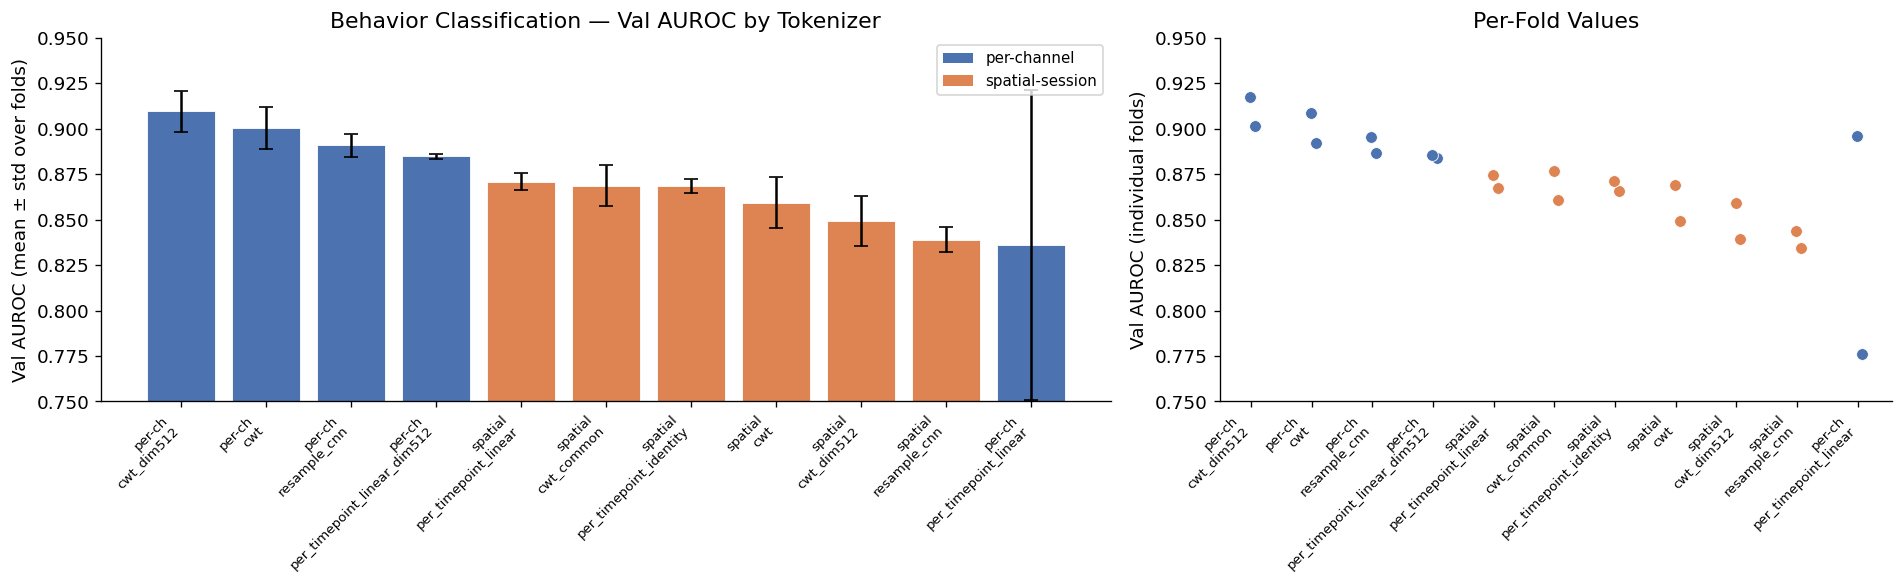

In [ ]:
from matplotlib.patches import Patch


def make_label(name):
    if "per_channel" in name:
        return f"per-ch\n{name.removeprefix('per_channel_')}"
    return f"spatial\n{name.removeprefix('spatial_session_')}"


def get_color(name):
    return "#4C72B0" if "per_channel" in name else "#DD8452"


SPATIAL_LEGEND = [
    Patch(facecolor="#4C72B0", label="per-channel"),
    Patch(facecolor="#DD8452", label="spatial-session"),
]

fig, axes = plt.subplots(
    1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [3, 2]}
)

# Left: bar chart with error bars
ax = axes[0]
bs = behavior_summary.reset_index()
colors = [get_color(t) for t in bs["tokenizer"]]
ax.bar(
    range(len(bs)),
    bs["val_auroc_mean"],
    yerr=bs["val_auroc_std"],
    capsize=4,
    color=colors,
    edgecolor="white",
    linewidth=0.5,
)
ax.set_xticks(range(len(bs)))
ax.set_xticklabels(
    [make_label(t) for t in bs["tokenizer"]],
    rotation=45,
    ha="right",
    fontsize=8,
)
ax.set_ylabel("Val AUROC (mean ± std over folds)")
ax.set_title("Behavior Classification — Val AUROC by Tokenizer")
ax.legend(handles=SPATIAL_LEGEND, loc="upper right", fontsize=9)
ax.set_ylim(0.75, 0.95)

# Right: strip plot showing individual fold values
ax2 = axes[1]
order = bs["tokenizer"].tolist()
for i, tok in enumerate(order):
    fold_vals = df_behavior[df_behavior["tokenizer"] == tok]["val_auroc"].values
    jitter = np.random.default_rng(42).uniform(-0.12, 0.12, size=len(fold_vals))
    ax2.scatter(
        [i + j for j in jitter],
        fold_vals,
        c=get_color(tok),
        s=50,
        edgecolors="white",
        linewidth=0.5,
        zorder=3,
    )
ax2.set_xticks(range(len(order)))
ax2.set_xticklabels(
    [make_label(t) for t in order], rotation=45, ha="right", fontsize=8
)
ax2.set_ylabel("Val AUROC (individual folds)")
ax2.set_title("Per-Fold Values")
ax2.set_ylim(0.75, 0.95)

plt.tight_layout()
plt.show()

### Per-fold detail (behavior)

In [7]:
behavior_pivot = df_behavior.pivot(
    index="tokenizer", columns="fold", values="val_auroc"
).rename(columns={0: "fold_0", 1: "fold_1"})
behavior_pivot["mean"] = behavior_pivot.mean(axis=1)
behavior_pivot.sort_values("mean", ascending=False).round(4)

fold,fold_0,fold_1,mean
tokenizer,,,
per_channel_cwt_dim512,0.9016,0.9175,0.9095
per_channel_cwt,0.8923,0.9086,0.9005
per_channel_resample_cnn,0.8865,0.8954,0.8909
per_channel_per_timepoint_linear_dim512,0.8837,0.8857,0.8847
spatial_session_per_timepoint_linear,0.8674,0.8743,0.8709
spatial_session_cwt_common,0.8606,0.8767,0.8687
spatial_session_per_timepoint_identity,0.8658,0.8711,0.8684
spatial_session_cwt,0.8492,0.8691,0.8591
spatial_session_cwt_dim512,0.8395,0.8591,0.8493


### Overfitting analysis (behavior)

The gap between train and validation metrics can reveal capacity/regularization issues.

In [8]:
overfit_df = df_behavior.groupby("tokenizer").agg(
    train_auroc=("train_auroc", "mean"),
    val_auroc=("val_auroc", "mean"),
    train_loss=("train_loss", "mean"),
    val_loss=("val_loss", "mean"),
)
overfit_df["auroc_gap"] = overfit_df["train_auroc"] - overfit_df["val_auroc"]
overfit_df["loss_gap"] = overfit_df["val_loss"] - overfit_df["train_loss"]
overfit_df.sort_values("auroc_gap", ascending=False).round(4)

,train_auroc,val_auroc,train_loss,val_loss,auroc_gap,loss_gap
tokenizer,,,,,,
spatial_session_resample_cnn,0.9887,0.8390,0.1088,0.8742,0.1497,0.7654
spatial_session_per_timepoint_identity,0.9965,0.8684,0.0917,0.8432,0.1280,0.7516
spatial_session_cwt_dim512,0.9766,0.8493,0.1626,0.8733,0.1273,0.7107
spatial_session_cwt,0.9833,0.8591,0.2061,0.8563,0.1242,0.6502
spatial_session_per_timepoint_linear,0.9947,0.8709,0.0856,0.8411,0.1238,0.7556
spatial_session_cwt_common,0.9820,0.8687,0.2333,0.8365,0.1133,0.6032
per_channel_cwt,0.9716,0.9005,0.2153,0.7860,0.0712,0.5707
per_channel_cwt_dim512,0.9763,0.9095,0.2051,0.7645,0.0667,0.5594
per_channel_resample_cnn,0.9485,0.8909,0.3215,0.7930,0.0575,0.4715


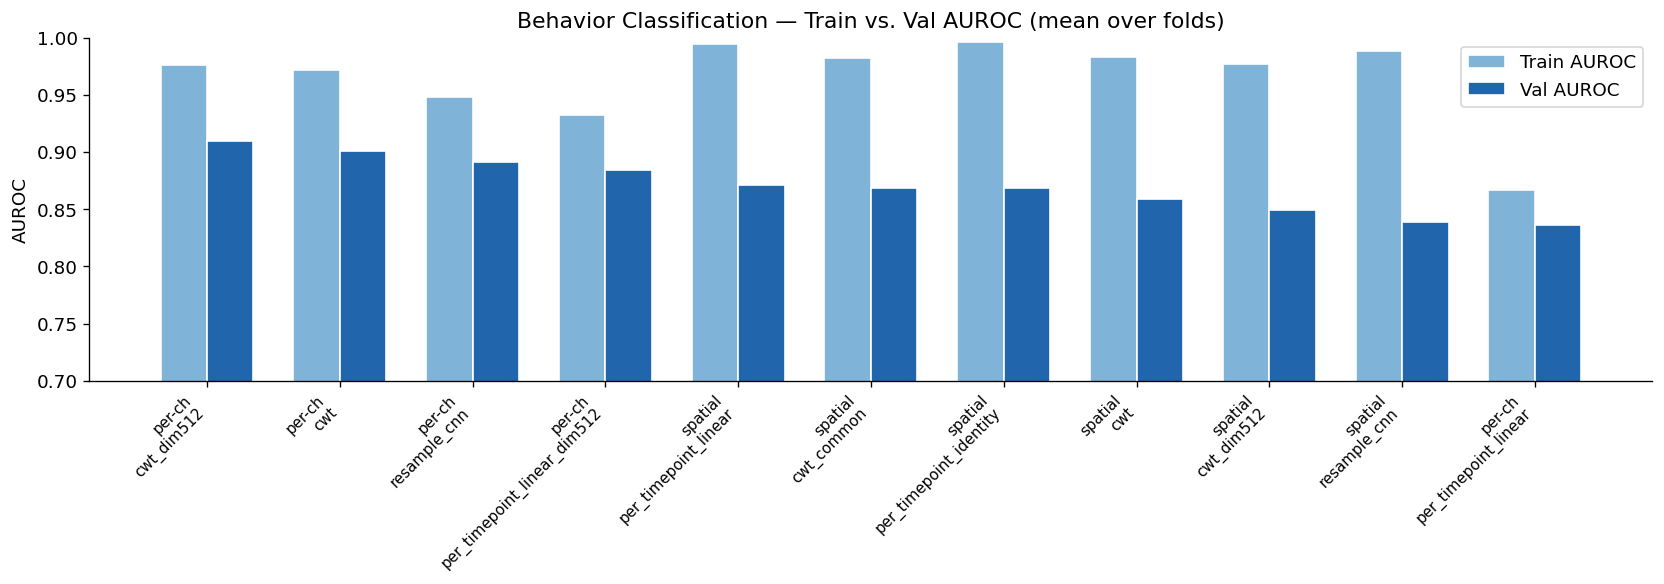

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
od = overfit_df.sort_values("val_auroc", ascending=False).reset_index()

x = np.arange(len(od))
width = 0.35

ax.bar(
    x - width / 2,
    od["train_auroc"],
    width,
    label="Train AUROC",
    color="#7FB3D8",
    edgecolor="white",
)
ax.bar(
    x + width / 2,
    od["val_auroc"],
    width,
    label="Val AUROC",
    color="#2166AC",
    edgecolor="white",
)

ax.set_xticks(x)
ax.set_xticklabels(
    [make_label(t) for t in od["tokenizer"]],
    rotation=45,
    ha="right",
    fontsize=9,
)
ax.set_ylabel("AUROC")
ax.set_title("Behavior Classification — Train vs. Val AUROC (mean over folds)")
ax.legend()
ax.set_ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

## 4. Pose estimation results (fold 0 only)

Due to a bug, pose estimation results for fold 1 are unreliable. We present fold 0 results only.

In [10]:
df_pose_f0 = df_pose[df_pose["fold"] == 0].copy()

pose_summary = df_pose_f0.set_index("tokenizer")[
    ["val_r2", "val_mse", "val_mae", "val_loss", "train_r2", "train_loss"]
].sort_values("val_r2", ascending=False)
pose_summary.round(4)

,val_r2,val_mse,val_mae,val_loss,train_r2,train_loss
tokenizer,,,,,,
per_channel_resample_cnn,0.3237,0.6604,0.5088,0.6604,0.5475,0.2282
per_channel_cwt,0.3119,0.6720,0.5209,0.6720,0.4519,0.2289
spatial_session_cwt_common,0.3065,0.6772,0.5175,0.6772,0.5173,0.3652
spatial_session_per_timepoint_linear,0.2258,0.7565,0.5615,0.7565,0.4183,0.4581
spatial_session_resample_cnn,0.2198,0.7620,0.5742,0.7620,0.3897,0.4744
per_channel_per_timepoint_linear,0.1989,0.7825,0.6016,0.7825,0.2251,0.3392


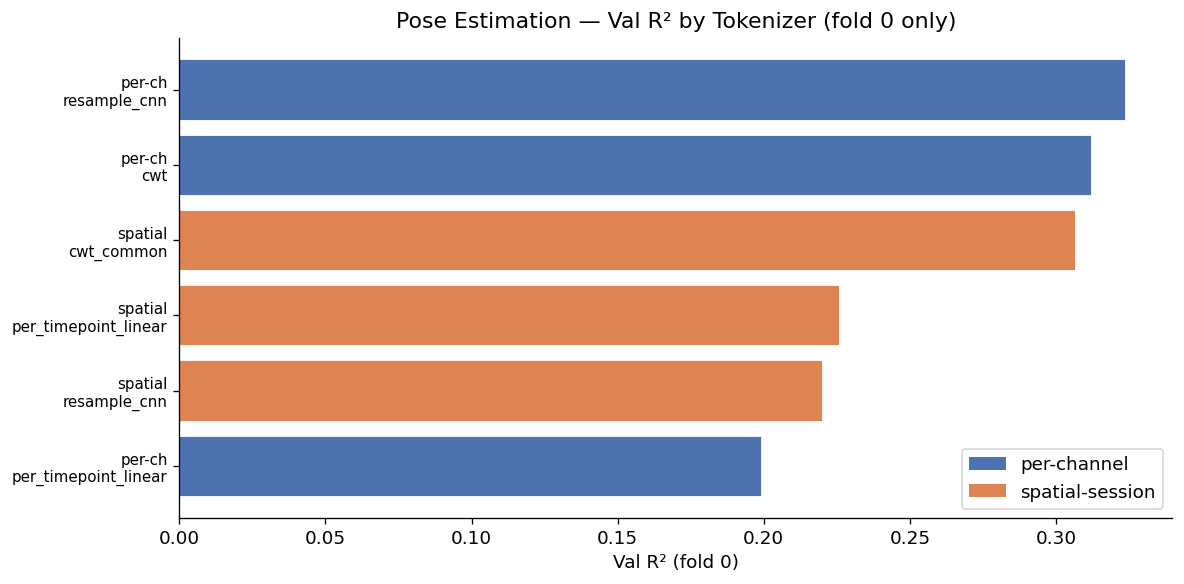

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ps = pose_summary.reset_index()

colors = [get_color(t) for t in ps["tokenizer"]]
ax.barh(
    range(len(ps)), ps["val_r2"], color=colors, edgecolor="white", linewidth=0.5
)

ax.set_yticks(range(len(ps)))
ax.set_yticklabels([make_label(t) for t in ps["tokenizer"]], fontsize=9)
ax.set_xlabel("Val R² (fold 0)")
ax.set_title("Pose Estimation — Val R² by Tokenizer (fold 0 only)")
ax.invert_yaxis()
ax.legend(handles=SPATIAL_LEGEND, loc="lower right")
plt.tight_layout()
plt.show()

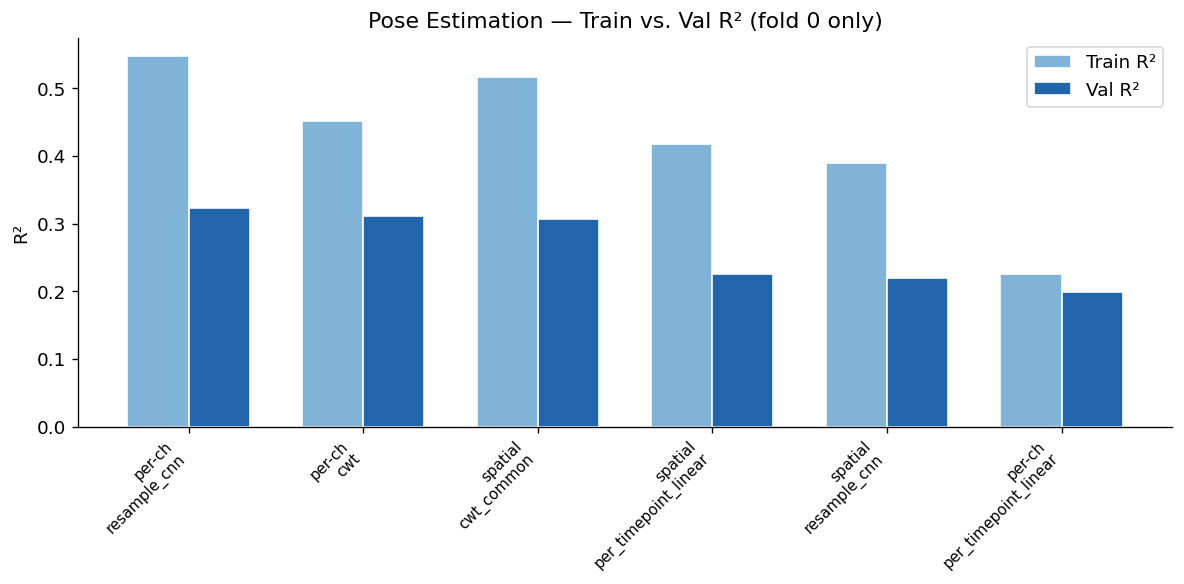

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ps = pose_summary.reset_index()

x = np.arange(len(ps))
width = 0.35

ax.bar(
    x - width / 2,
    ps["train_r2"],
    width,
    label="Train R²",
    color="#7FB3D8",
    edgecolor="white",
)
ax.bar(
    x + width / 2,
    ps["val_r2"],
    width,
    label="Val R²",
    color="#2166AC",
    edgecolor="white",
)

ax.set_xticks(x)
ax.set_xticklabels(
    [make_label(t) for t in ps["tokenizer"]],
    rotation=45,
    ha="right",
    fontsize=9,
)
ax.set_ylabel("R²")
ax.set_title("Pose Estimation — Train vs. Val R² (fold 0 only)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Structured comparisons

### Q1: Spatial-session vs. per-channel (matched temporal embeddings)

In [13]:
PAIRED_COMPARISONS = [
    ("per_channel_cwt", "spatial_session_cwt"),
    ("per_channel_resample_cnn", "spatial_session_resample_cnn"),
    (
        "per_channel_per_timepoint_linear",
        "spatial_session_per_timepoint_linear",
    ),
]

beh_mean = df_behavior.groupby("tokenizer")["val_auroc"].mean()

print("Behavior classification (Val AUROC, mean over folds):")
print(
    f"{'Temporal':>30s}  {'per-channel':>12s}  {'spatial-session':>15s}  {'Δ (pc - ss)':>12s}"
)
print("-" * 75)
for pc, ss in PAIRED_COMPARISONS:
    temporal = pc.removeprefix("per_channel_")
    pc_val = beh_mean.get(pc, float("nan"))
    ss_val = beh_mean.get(ss, float("nan"))
    delta = pc_val - ss_val
    print(f"{temporal:>30s}  {pc_val:>12.4f}  {ss_val:>15.4f}  {delta:>+12.4f}")

print()
pose_f0_idx = df_pose_f0.set_index("tokenizer")["val_r2"]

print("Pose estimation (Val R², fold 0 only):")
print(
    f"{'Temporal':>30s}  {'per-channel':>12s}  {'spatial-session':>15s}  {'Δ (pc - ss)':>12s}"
)
print("-" * 75)
POSE_PAIRS = [
    ("per_channel_cwt", "spatial_session_cwt_common"),
    ("per_channel_resample_cnn", "spatial_session_resample_cnn"),
    (
        "per_channel_per_timepoint_linear",
        "spatial_session_per_timepoint_linear",
    ),
]
for pc, ss in POSE_PAIRS:
    temporal = pc.removeprefix("per_channel_")
    pc_val = pose_f0_idx.get(pc, float("nan"))
    ss_val = pose_f0_idx.get(ss, float("nan"))
    delta = pc_val - ss_val
    print(f"{temporal:>30s}  {pc_val:>12.4f}  {ss_val:>15.4f}  {delta:>+12.4f}")

Behavior classification (Val AUROC, mean over folds):
                      Temporal   per-channel  spatial-session   Δ (pc - ss)
---------------------------------------------------------------------------
                           cwt        0.9005           0.8591       +0.0413
                  resample_cnn        0.8909           0.8390       +0.0520
          per_timepoint_linear        0.8360           0.8709       -0.0349

Pose estimation (Val R², fold 0 only):
                      Temporal   per-channel  spatial-session   Δ (pc - ss)
---------------------------------------------------------------------------
                           cwt        0.3119           0.3065       +0.0054
                  resample_cnn        0.3237           0.2198       +0.1039
          per_timepoint_linear        0.1989           0.2258       -0.0269


### Q2: Temporal embedding comparison (CWT vs. ResampleCNN vs. PerTimepointLinear)

In [14]:
temporal_methods = ["cwt", "resample_cnn", "per_timepoint_linear"]

print("=== Behavior (Val AUROC, mean over folds) ===")
print(f"{'Channel strategy':>20s}", end="")
for t in temporal_methods:
    print(f"  {t:>22s}", end="")
print()

for spatial in ["per_channel", "spatial_session"]:
    print(f"{spatial:>20s}", end="")
    for t in temporal_methods:
        key = f"{spatial}_{t}"
        val = beh_mean.get(key, float("nan"))
        print(f"  {val:>22.4f}", end="")
    print()

print()
print("=== Pose (Val R², fold 0 only) ===")
print(f"{'Channel strategy':>20s}", end="")
for t in temporal_methods:
    print(f"  {t:>22s}", end="")
print()

for spatial in ["per_channel", "spatial_session"]:
    print(f"{spatial:>20s}", end="")
    for t in temporal_methods:
        key = f"{spatial}_{t}"
        if spatial == "spatial_session" and t == "cwt":
            key = "spatial_session_cwt_common"
        val = pose_f0_idx.get(key, float("nan"))
        print(f"  {val:>22.4f}", end="")
    print()

=== Behavior (Val AUROC, mean over folds) ===
    Channel strategy                     cwt            resample_cnn    per_timepoint_linear
         per_channel                  0.9005                  0.8909                  0.8360
     spatial_session                  0.8591                  0.8390                  0.8709

=== Pose (Val R², fold 0 only) ===
    Channel strategy                     cwt            resample_cnn    per_timepoint_linear
         per_channel                  0.3119                  0.3237                  0.1989
     spatial_session                  0.3065                  0.2198                  0.2258


### Q3: Effect of embed_dim (256 vs. 512)

In [15]:
DIM_PAIRS = [
    ("per_channel_cwt", "per_channel_cwt_dim512"),
    ("spatial_session_cwt", "spatial_session_cwt_dim512"),
    (
        "per_channel_per_timepoint_linear",
        "per_channel_per_timepoint_linear_dim512",
    ),
]

print("Behavior (Val AUROC, mean over folds):")
print(f"{'Tokenizer':>45s}  {'dim256':>8s}  {'dim512':>8s}  {'Δ':>8s}")
print("-" * 75)
for base, big in DIM_PAIRS:
    v256 = beh_mean.get(base, float("nan"))
    v512 = beh_mean.get(big, float("nan"))
    delta = v512 - v256
    print(f"{base:>45s}  {v256:>8.4f}  {v512:>8.4f}  {delta:>+8.4f}")

Behavior (Val AUROC, mean over folds):
                                    Tokenizer    dim256    dim512         Δ
---------------------------------------------------------------------------
                              per_channel_cwt    0.9005    0.9095   +0.0091
                          spatial_session_cwt    0.8591    0.8493   -0.0099
             per_channel_per_timepoint_linear    0.8360    0.8847   +0.0487


### Q4: Effect of common layer and identity embedding (behavior)

In [16]:
VARIANT_COMPARISONS = [
    ("spatial_session_cwt", "spatial_session_cwt_common", "+ common_layer"),
    (
        "spatial_session_per_timepoint_linear",
        "spatial_session_per_timepoint_identity",
        "linear → identity",
    ),
]

print("Behavior (Val AUROC, mean over folds):")
print(
    f"{'Base':>40s}  {'Variant':>40s}  {'Base AUROC':>10s}  {'Var AUROC':>10s}  {'Δ':>8s}"
)
print("-" * 115)
for base, variant, desc in VARIANT_COMPARISONS:
    v_base = beh_mean.get(base, float("nan"))
    v_var = beh_mean.get(variant, float("nan"))
    delta = v_var - v_base
    print(
        f"{base:>40s}  {variant + ' (' + desc + ')':>40s}  {v_base:>10.4f}  {v_var:>10.4f}  {delta:>+8.4f}"
    )

Behavior (Val AUROC, mean over folds):
                                    Base                                   Variant  Base AUROC   Var AUROC         Δ
-------------------------------------------------------------------------------------------------------------------
                     spatial_session_cwt  spatial_session_cwt_common (+ common_layer)      0.8591      0.8687   +0.0095
    spatial_session_per_timepoint_linear  spatial_session_per_timepoint_identity (linear → identity)      0.8709      0.8684   -0.0024


## 6. Evaluation of proposed limitations

The following limitations were raised regarding the experimental design. We examine each against the actual implementation and results.

---

### Limitation 1: "Geometric Aliasing" — bilinear `grid_sample` without low-pass filtering

**Claim:** Using `F.grid_sample` with bilinear interpolation to downsample raw sequences (e.g. 500→200 tokens) without prior low-pass filtering aliases high-frequency neural data, artificially crippling the CNN baseline.

**What the code actually does:**

Both `ResampleCNNEmbedding` and `CWTEmbedding` use `F.grid_sample` with `mode="bilinear"` to resample along the time axis. Bilinear interpolation on a 1-D signal is equivalent to linear interpolation — a tent filter, which is *not* an ideal low-pass (its frequency response has non-zero sidelobes and only -6dB attenuation at the new Nyquist).

For `ResampleCNNEmbedding`, the 2-layer CNN (kernel=7) *follows* the resampling. If aliasing has already folded high-frequency content into the resampled signal, the CNN cannot undo it. However, the CNN *could* learn to attenuate aliased components if they are detrimental.

For `CWTEmbedding`, `grid_sample` resamples the *wavelet coefficients* (a time–frequency map), not the raw signal. Since each wavelet frequency band is already band-limited by the Morlet envelope, the CWT output at each frequency is inherently smoother than the raw signal. Aliasing from resampling the CWT map is therefore less severe.

**Assessment:** This is a *valid concern for `ResampleCNNEmbedding`* specifically. The linear resampling before CNN processing does not satisfy the Nyquist criterion when downsampling from ~500 to 200 samples. This could introduce aliased spectral content that the CNN then processes. However, whether this "severely" impacts results depends on the signal's spectral content relative to the new Nyquist frequency (~100 Hz after resampling a 500 Hz signal to 200 samples in 1s). ECoG signals above 100 Hz (high gamma) do carry information, so some aliasing is plausible. The CWT path is less affected because it resamples already-bandlimited wavelet coefficients.

The `PerTimepointLinear` embedding does *not* use resampling at all — it processes each raw time sample independently — so it is not subject to this limitation.

### Limitation 2: "Receptive Field Asymmetry" — CNN vs. CWT temporal context

**Claim:** The CNN's effective receptive field (~35ms) is vastly smaller than the CWT's (~1.4s for a 5 Hz theta wave), making it impossible for the CNN to learn low-frequency dynamics.

**What the code actually does:**

The `ResampleCNNEmbedding` uses 2 Conv1d layers with kernel_size=7 and same padding. After resampling to 200 tokens over 1 second:
- Effective receptive field = `1 + num_layers × (kernel_size - 1)` = `1 + 2 × 6 = 13` tokens
- At 200 tokens/s → 13/200 = **65 ms** (not 35ms as claimed, but still narrow)

The CWT with `n_cycles ≈ 5–7` and lowest frequency ~1.4 Hz (learned) has a Gaussian envelope spanning `σ = n_cycles / (2π·f)` ≈ 0.6–0.8 seconds at the lowest frequency. The FFT convolution covers the entire 1-second window.

**Assessment:** The core concern is *partially valid* but overstated. The CNN does have a limited receptive field in its convolutional layers (~65ms, not 35ms). However, two important caveats:

1. The CNN tokens are fed into the Perceiver backbone, which has full self- and cross-attention across all 200 time tokens. The backbone can learn long-range temporal dependencies — the CNN only determines the *per-token feature extraction* receptive field.
2. The claim about "~35ms" appears to assume a raw sampling rate, but the CNN operates *after* resampling to 200 tokens/s, giving it slightly more temporal context per kernel position.

That said, the CWT *does* extract explicit frequency-domain features before the backbone, giving it a structural advantage for capturing oscillatory dynamics. The CNN must rely on the backbone's attention to integrate across time, which is a less direct pathway for frequency-selective processing.

### Limitation 3: "The Perceiver Blindfold" — static spatial pre-mixing

**Claim:** Using a single linear layer to collapse the channel dimension (`spatial_session`) statically pre-mixes the spatial data, completely depriving the Perceiver backbone of dynamic, trial-by-trial spatial cross-attention.

**What the code actually does:**

`SessionSpatialProjector` applies a per-session `Linear(num_channels → num_sources)` to each timepoint independently. This is a **static, session-specific** spatial mixing — the same projection is applied regardless of the trial content. The backbone receives tokens from the projected sources, with no access to per-channel identity or raw per-channel signals.

In contrast, `PerChannelStrategy` preserves individual channel identities. Each channel is processed by the temporal embedding independently, and channel identity embeddings are added to the resulting tokens. The backbone can then attend across all channel × time tokens, enabling dynamic cross-channel attention.

**Assessment:** This is a *valid architectural observation*. The spatial projection does remove the backbone's ability to perform dynamic spatial attention. However, whether this is a "blindfold" depends on the task:

- If optimal spatial weighting varies trial-by-trial (e.g., due to changing neural states), static projection is suboptimal.
- If the relevant spatial patterns are consistent within a session, a learned linear projection may be sufficient and more parameter-efficient.

The results can inform which regime applies here. Note that `per_channel` creates `C × T_tokens` tokens while `spatial_session` creates only `T_tokens` tokens — a large difference in sequence length for the backbone, which affects both computational cost and the attention distribution.

In [17]:
print(
    "Token count comparison (1s window, 200 target time tokens, ~64 ECoG channels):"
)
print(f"  per_channel (CWT/CNN):       64 × 200 = {64 * 200:,} tokens")
print(
    f"  per_channel (per_timepoint):  64 × 500 = {64 * 500:,} tokens (at 500 Hz)"
)
print("  spatial_session (CWT/CNN):    200 tokens")
print("  spatial_session (per_timepoint): 500 tokens (at 500 Hz)")
print()
print("The ~64× token count difference between per-channel and spatial-session")
print(
    "means the backbone processes very different sequence lengths, which affects"
)
print("attention computational cost and per-token attention budget.")

Token count comparison (1s window, 200 target time tokens, ~64 ECoG channels):
  per_channel (CWT/CNN):       64 × 200 = 12,800 tokens
  per_channel (per_timepoint):  64 × 500 = 32,000 tokens (at 500 Hz)
  spatial_session (CWT/CNN):    200 tokens
  spatial_session (per_timepoint): 500 tokens (at 500 Hz)

The ~64× token count difference between per-channel and spatial-session
means the backbone processes very different sequence lengths, which affects
attention computational cost and per-token attention budget.


### Limitation 5: "Hyperparameter Sabotage" — shared hyperparameters across architectures

**Claim:** Running hyperparameter tuning on only one architecture and applying those settings to all others virtually guarantees suboptimal performance for the non-tuned architectures.

**What the experiments actually used:**

In [18]:
print("All runs in both experiments used identical hyperparameters:")
print("  learning_rate:  0.0006")
print("  weight_decay:   0.09")
print("  batch_size:     64 (effective 1024 via accumulation)")
print("  embed_dim:      256 (or 512 for *_dim512 variants)")
print("  max_epochs:     10000 (with early stopping, patience=20)")
print()
print("These were NOT tuned per-tokenizer. All tokenizers share the same")
print("learning rate, weight decay, and training schedule.")

All runs in both experiments used identical hyperparameters:
  learning_rate:  0.0006
  weight_decay:   0.09
  batch_size:     64 (effective 1024 via accumulation)
  embed_dim:      256 (or 512 for *_dim512 variants)
  max_epochs:     10000 (with early stopping, patience=20)

These were NOT tuned per-tokenizer. All tokenizers share the same
learning rate, weight decay, and training schedule.


**Assessment:** This concern is *valid in principle* — different tokenizer architectures may have different optimal learning rates or regularization settings. However, the degree of impact is unclear:

- The shared hyperparameters (LR=6e-4, WD=0.09) are reasonable general-purpose values. Whether per-architecture tuning would meaningfully change the ranking is an open question.
- Early stopping with patience=20 provides some robustness to suboptimal learning rates by allowing each architecture to train for as many epochs as needed.
- The concern applies symmetrically to all architectures — if the hyperparameters happen to favor one tokenizer, the comparison is biased, but we cannot determine the direction of bias without running per-architecture sweeps.
- With 11 tokenizers × 2 tasks, running full hyperparameter sweeps for each would be expensive. Using shared hyperparameters is a common (if imperfect) practice in ablation studies.

The overfit analysis above provides some indirect signal: tokenizers with very high train AUROC but low val AUROC may benefit from different regularization.

### Limitation 6: "Intrasession Fallacy" — evaluation on intrasession splits only

**Claim:** Evaluating purely on intrasession splits only proves the model is a good subject-specific decoder, failing to validate cross-session or cross-subject generalization.

**What the experiments actually used:**

In [19]:
print("All runs used: split_type = intrasession")
print()
print("This means train/val splits come from the SAME recording sessions.")
print(
    "The model is evaluated on held-out time segments from sessions it trained on."
)
print()
print(
    "No intersession or cross-subject evaluation was performed in these experiments."
)

All runs used: split_type = intrasession

This means train/val splits come from the SAME recording sessions.
The model is evaluated on held-out time segments from sessions it trained on.

No intersession or cross-subject evaluation was performed in these experiments.


**Assessment:** This is a *valid limitation of the evaluation scope*, but context matters:

- For a **tokenizer ablation**, intrasession evaluation is a reasonable starting point — it isolates the tokenizer's ability to extract useful features from neural data without confounding session/subject variability.
- If the goal is to claim "foundational model" generalization, intrasession results are indeed insufficient. Cross-session and cross-subject evaluation would be needed.
- The spatial-session tokenizer architectures are specifically designed for cross-session flexibility (per-session projections), so their advantage may be *underestimated* in intrasession evaluation where session variability is absent.
- Conversely, per-channel tokenizers that rely on channel identity embeddings may have an advantage in intrasession settings where channel configurations are consistent.

## 7. Summary of observations

### Results summary

In [20]:
print("=" * 70)
print("BEHAVIOR CLASSIFICATION (Val AUROC, mean ± std over 2 folds)")
print("=" * 70)
for _, row in behavior_summary.iterrows():
    print(
        f"  {row.name:>50s}:  {row['val_auroc_mean']:.4f} ± {row['val_auroc_std']:.4f}"
    )

print()
print("=" * 70)
print("POSE ESTIMATION (Val R², fold 0 only)")
print("=" * 70)
for tok, row in pose_summary.iterrows():
    print(f"  {tok:>50s}:  {row['val_r2']:.4f}")

BEHAVIOR CLASSIFICATION (Val AUROC, mean ± std over 2 folds)
                              per_channel_cwt_dim512:  0.9095 ± 0.0112
                                     per_channel_cwt:  0.9005 ± 0.0115
                            per_channel_resample_cnn:  0.8909 ± 0.0063
             per_channel_per_timepoint_linear_dim512:  0.8847 ± 0.0014
                spatial_session_per_timepoint_linear:  0.8709 ± 0.0049
                          spatial_session_cwt_common:  0.8687 ± 0.0114
              spatial_session_per_timepoint_identity:  0.8684 ± 0.0037
                                 spatial_session_cwt:  0.8591 ± 0.0140
                          spatial_session_cwt_dim512:  0.8493 ± 0.0138
                        spatial_session_resample_cnn:  0.8390 ± 0.0068
                    per_channel_per_timepoint_linear:  0.8360 ± 0.0850

POSE ESTIMATION (Val R², fold 0 only)
                            per_channel_resample_cnn:  0.3237
                                     per_channel_cwt:  0.

### Key observations (without definitive conclusions)

1. **Per-channel consistently outperforms spatial-session** on behavior classification across all three temporal embeddings. The gap is substantial (3–6 AUROC points). For pose estimation, the picture is more mixed — per-channel CWT and ResampleCNN slightly edge out their spatial counterparts, but the margins are smaller.

2. **CWT-based tokenizers rank highest** on both tasks, whether per-channel or spatial-session. On behavior, per-channel CWT (dim 256 and 512) leads the ranking. On pose, per-channel ResampleCNN slightly edges out CWT.

3. **Large train–val gaps** for spatial-session variants (especially identity and per_timepoint_linear) suggest overfitting, which could indicate that these architectures are underregularized at the current hyperparameter settings.

4. **`embed_dim=512`** provides a modest improvement over 256 for per-channel CWT (+0.01 AUROC), but the spatial-session CWT at 512 performs *worse* on val while achieving very high train metrics — suggesting increased overfitting.

5. **The `common_layer` variant** for spatial-session CWT improves over the base spatial CWT on behavior (+0.01 AUROC), suggesting the shared post-projection layer adds useful cross-session regularization.

### Limitations to keep in mind when interpreting these results

| # | Limitation | Validity | Impact on interpretation |
|---|-----------|----------|------------------------|
| 1 | Aliasing from grid_sample resampling | Valid for ResampleCNN; less relevant for CWT | ResampleCNN results may be pessimistic; CWT resamples band-limited coefficients |
| 2 | CNN receptive field << CWT | Partially valid (~65ms vs full window) | CNN per-token features are local; backbone attention partially compensates |
| 3 | Static spatial projection | Valid architectural observation | spatial-session removes dynamic spatial attention; large token count asymmetry |
| 5 | Shared hyperparameters | Valid concern | Rankings could shift with per-architecture tuning; direction of bias unknown |
| 6 | Intrasession-only evaluation | Valid scope limitation | Results reflect within-session decoding only; cross-session conclusions cannot be drawn |